# 05 — Análise Final dos Dados

## 1. Objetivo da análise

Esta etapa tem como objetivo analisar os dados disponibilizados na camada Gold do pipeline e transformar os dados processados nas etapas anteriores em informações relevantes sobre o mercado imobiliário das cinco cidades presentes no conjunto de dados.

As análises serão realizadas sobre o modelo dimensional construído, relacionando a tabela fato `fato_mercado_imobiliario` às dimensões `dim_tempo`, `dim_localidade` e `dim_transacao`.

Considerando as variáveis disponíveis no conjunto de dados — período, cidade, bairro, tipo de transação, preço por metro quadrado, quantidade de anúncios e tempo médio dos imóveis no mercado — foram definidas as seguintes perguntas de negócio:

### Perguntas de negócio

1. Como o preço mediano por metro quadrado varia entre as cinco cidades analisadas?

2. Quais cidades apresentam os maiores e os menores preços medianos por metro quadrado para imóveis destinados à venda e ao aluguel?

3. Como o preço mediano por metro quadrado evoluiu ao longo do período analisado em cada cidade?

4. Como se comporta a oferta de imóveis nas cidades analisadas, considerando a quantidade média de anúncios ativos e a entrada de novos anúncios?

5. Existem diferenças no tempo médio de permanência dos imóveis no mercado entre as cidades e entre os tipos de transação?

6. Quais bairros apresentam os maiores preços medianos por metro quadrado em cada cidade?

As perguntas serão respondidas individualmente por meio de consultas sobre a camada Gold, acompanhadas de resultados quantitativos, visualizações e interpretação dos resultados no contexto do mercado imobiliário.

## 5.1 Pergunta 1 — Comparação do preço por metro quadrado entre as cidades

**Pergunta:** Como o preço mediano por metro quadrado varia entre as cinco cidades analisadas?

Para comparar as cidades, será calculada a mediana das observações disponíveis de `mediana_m2` para cada cidade. A utilização da mediana reduz a influência dos valores extremos identificados durante a avaliação da qualidade dos dados.

Os registros em que `mediana_m2` está ausente serão desconsiderados exclusivamente neste cálculo.

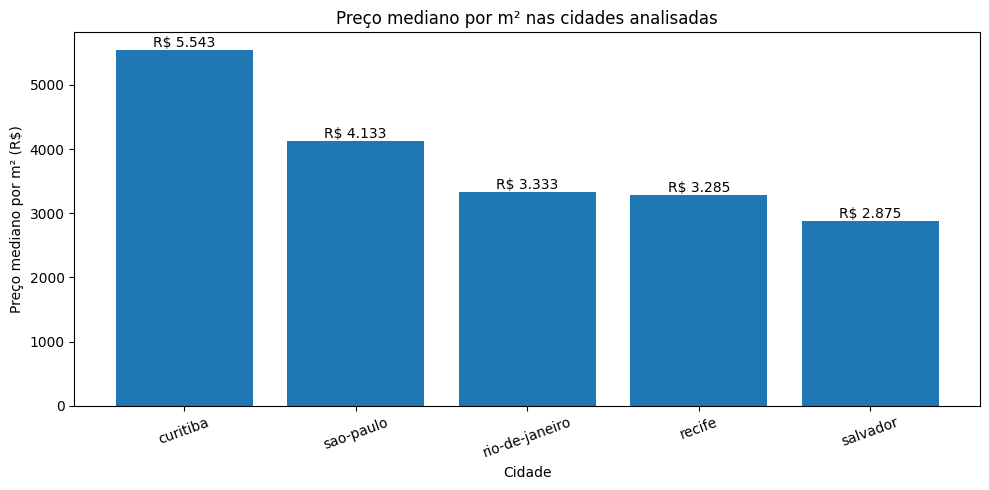

In [0]:
from pyspark.sql.functions import col, percentile_approx
import matplotlib.pyplot as plt

# Relacionamento da tabela fato com a dimensão Localidade
df_analise = (
    spark.table("mvp_imobiliario.gold.fato_mercado_imobiliario").alias("f")
    .join(
        spark.table("mvp_imobiliario.gold.dim_localidade").alias("l"),
        col("f.id_localidade") == col("l.id_localidade"),
        "inner"
    )
)

# Cálculo do preço mediano por m² para cada cidade
resultado_p1 = (
    df_analise
    .filter(col("f.mediana_m2").isNotNull())
    .groupBy(col("l.cidade").alias("cidade"))
    .agg(
        percentile_approx(
            col("f.mediana_m2"), 0.5
        ).alias("preco_mediano_m2")
    )
    .orderBy(col("preco_mediano_m2").desc())
)

# Conversão do resultado agregado para Pandas
pdf_p1 = resultado_p1.toPandas()

# Construção do gráfico
plt.figure(figsize=(10, 5))

barras = plt.bar(
    pdf_p1["cidade"],
    pdf_p1["preco_mediano_m2"]
)

plt.title("Preço mediano por m² nas cidades analisadas")
plt.xlabel("Cidade")
plt.ylabel("Preço mediano por m² (R$)")
plt.xticks(rotation=20)

# Inclusão dos valores sobre as barras
for barra, valor in zip(barras, pdf_p1["preco_mediano_m2"]):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"R$ {valor:,.0f}".replace(",", "."),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 5.1.1 Interpretação do resultado

A comparação evidencia diferenças relevantes no preço mediano por metro quadrado entre as cinco cidades analisadas. Curitiba apresentou o maior valor, com aproximadamente R$ 5.543/m², seguida por São Paulo, com R$ 4.133/m². Rio de Janeiro e Recife apresentaram valores próximos, de R$ 3.333/m² e R$ 3.285/m², respectivamente. Salvador apresentou o menor preço mediano entre as cidades analisadas, com aproximadamente R$ 2.875/m².

Considerando os dados disponíveis no conjunto analisado, o preço mediano por metro quadrado em Curitiba é aproximadamente 93% superior ao observado em Salvador, demonstrando uma diferença expressiva entre os extremos da amostra.

É importante destacar que esses resultados representam exclusivamente os registros presentes na base utilizada neste projeto e não devem ser interpretados como uma estimativa oficial dos preços imobiliários de cada cidade. Além disso, a utilização da mediana reduz a influência dos valores extremos identificados durante a etapa de avaliação da qualidade dos dados.

## 5.2 Pergunta 2 — Comparação dos preços entre venda e aluguel

**Pergunta:** Quais cidades apresentam os maiores e os menores preços medianos por metro quadrado para imóveis destinados à venda e ao aluguel?

Nesta análise, o preço mediano por metro quadrado será calculado separadamente para cada cidade e tipo de transação (`venda` e `aluguel`). Essa separação permite verificar se o comportamento dos preços apresenta diferenças entre os dois segmentos do mercado imobiliário.

Assim como na análise anterior, serão considerados apenas os registros que possuem valor válido para `mediana_m2`, utilizando a mediana como medida de comparação para reduzir a influência dos valores extremos identificados durante a avaliação da qualidade dos dados.

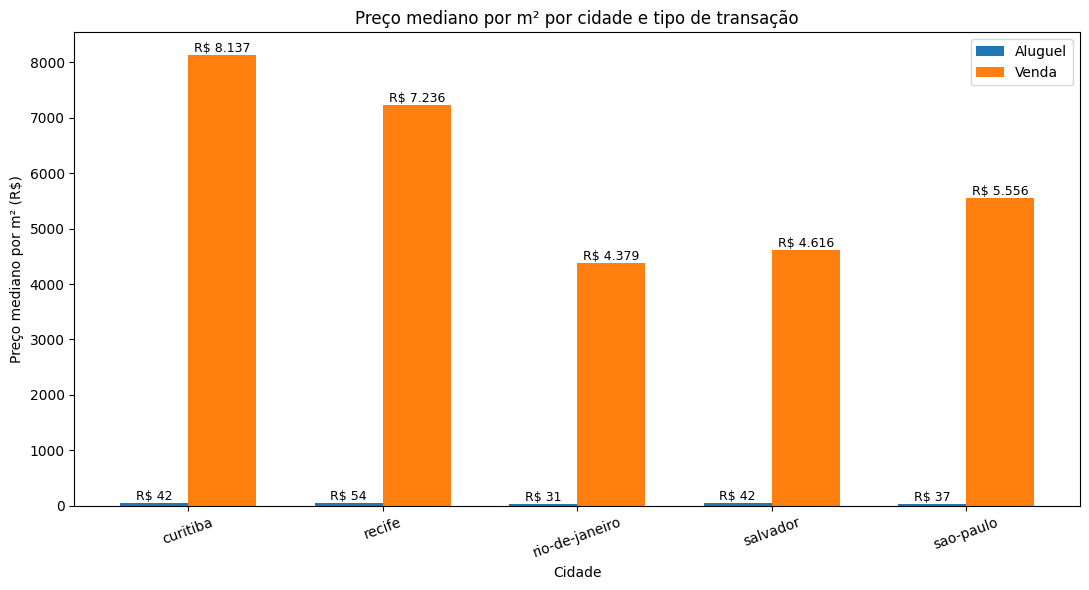

In [0]:
from pyspark.sql.functions import col, percentile_approx
import matplotlib.pyplot as plt
import numpy as np

# Relacionamento da tabela fato com as dimensões
df_p2 = (
    spark.table("mvp_imobiliario.gold.fato_mercado_imobiliario").alias("f")
    .join(
        spark.table("mvp_imobiliario.gold.dim_localidade").alias("l"),
        col("f.id_localidade") == col("l.id_localidade"),
        "inner"
    )
    .join(
        spark.table("mvp_imobiliario.gold.dim_transacao").alias("t"),
        col("f.id_transacao") == col("t.id_transacao"),
        "inner"
    )
)

# Cálculo da mediana por cidade e tipo de transação
resultado_p2 = (
    df_p2
    .filter(col("f.mediana_m2").isNotNull())
    .groupBy(
        col("l.cidade").alias("cidade"),
        col("t.transacao").alias("transacao")
    )
    .agg(
        percentile_approx(
            col("f.mediana_m2"), 0.5
        ).alias("preco_mediano_m2")
    )
)

# Conversão do resultado agregado para Pandas
pdf_p2 = resultado_p2.toPandas()

# Organização dos dados para o gráfico
grafico_p2 = (
    pdf_p2
    .pivot(
        index="cidade",
        columns="transacao",
        values="preco_mediano_m2"
    )
    .sort_index()
)

# Construção do gráfico
cidades = grafico_p2.index
x = np.arange(len(cidades))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_aluguel = ax.bar(
    x - largura / 2,
    grafico_p2["aluguel"],
    largura,
    label="Aluguel"
)

barras_venda = ax.bar(
    x + largura / 2,
    grafico_p2["venda"],
    largura,
    label="Venda"
)

ax.set_title("Preço mediano por m² por cidade e tipo de transação")
ax.set_xlabel("Cidade")
ax.set_ylabel("Preço mediano por m² (R$)")
ax.set_xticks(x)
ax.set_xticklabels(cidades, rotation=20)
ax.legend()

# Valores sobre as barras
for barras in [barras_aluguel, barras_venda]:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor,
            f"R$ {valor:,.0f}".replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

### 5.2.1 Interpretação do resultado

A análise por tipo de transação demonstra diferenças relevantes entre as cinco cidades. No segmento de venda, Curitiba apresentou o maior preço mediano por metro quadrado, com aproximadamente R$ 8.137/m², seguida por Recife (R$ 7.236/m²), São Paulo (R$ 5.556/m²), Salvador (R$ 4.616/m²) e Rio de Janeiro (R$ 4.379/m²).

No segmento de aluguel, Recife apresentou o maior valor mediano, com aproximadamente R$ 54/m², seguida por Curitiba e Salvador, ambas com R$ 42/m², São Paulo com R$ 37/m² e Rio de Janeiro com R$ 31/m².

Dessa forma, os dados analisados indicam que Curitiba apresenta o maior preço mediano por metro quadrado para venda, enquanto Recife apresenta o maior valor para aluguel. O Rio de Janeiro apresentou os menores valores medianos entre as cinco cidades nos dois tipos de transação.

Os resultados referem-se exclusivamente ao conjunto de dados utilizado neste projeto e ao período nele representado, não devendo ser interpretados como valores oficiais do mercado imobiliário dessas cidades.

## 5.3 Pergunta 3 — Evolução temporal do preço por metro quadrado

**Pergunta:** Como o preço mediano por metro quadrado evoluiu ao longo do período analisado em cada cidade?

Nesta análise será observada a evolução mensal do preço mediano por metro quadrado nas cinco cidades presentes no conjunto de dados. Para cada combinação de mês e cidade será calculada a mediana dos valores disponíveis de `mediana_m2`.

A análise temporal permite identificar variações, tendências e possíveis oscilações nos preços ao longo do período compreendido entre setembro de 2025 e setembro de 2026. Os registros sem informação de preço serão desconsiderados exclusivamente para o cálculo da mediana.

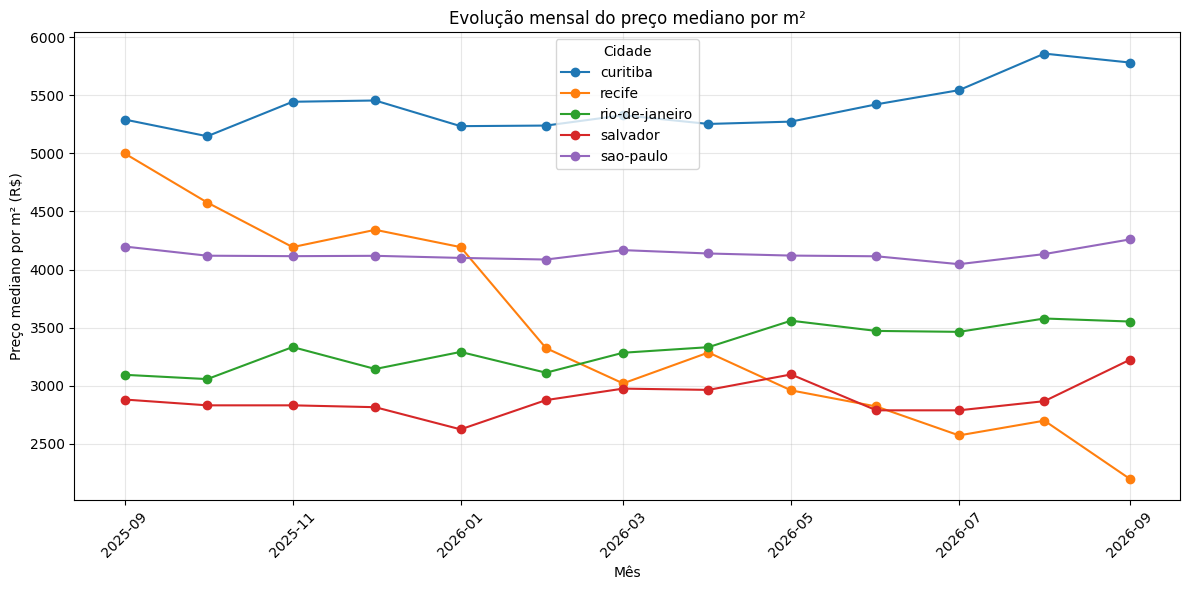

In [0]:
from pyspark.sql.functions import col, percentile_approx
import matplotlib.pyplot as plt

# Relacionamento da tabela fato com as dimensões Tempo e Localidade
df_p3 = (
    spark.table("mvp_imobiliario.gold.fato_mercado_imobiliario").alias("f")
    .join(
        spark.table("mvp_imobiliario.gold.dim_tempo").alias("t"),
        col("f.id_tempo") == col("t.id_tempo"),
        "inner"
    )
    .join(
        spark.table("mvp_imobiliario.gold.dim_localidade").alias("l"),
        col("f.id_localidade") == col("l.id_localidade"),
        "inner"
    )
)

# Cálculo do preço mediano por mês e cidade
resultado_p3 = (
    df_p3
    .filter(col("f.mediana_m2").isNotNull())
    .groupBy(
        col("t.mes").alias("mes"),
        col("l.cidade").alias("cidade")
    )
    .agg(
        percentile_approx(
            col("f.mediana_m2"), 0.5
        ).alias("preco_mediano_m2")
    )
    .orderBy("mes", "cidade")
)

# Conversão para Pandas
pdf_p3 = resultado_p3.toPandas()

# Garantia de ordenação cronológica
pdf_p3["mes"] = pdf_p3["mes"].astype("datetime64[ns]")
pdf_p3 = pdf_p3.sort_values("mes")

# Construção do gráfico
plt.figure(figsize=(12, 6))

for cidade in sorted(pdf_p3["cidade"].unique()):
    dados_cidade = pdf_p3[pdf_p3["cidade"] == cidade]

    plt.plot(
        dados_cidade["mes"],
        dados_cidade["preco_mediano_m2"],
        marker="o",
        label=cidade
    )

plt.title("Evolução mensal do preço mediano por m²")
plt.xlabel("Mês")
plt.ylabel("Preço mediano por m² (R$)")
plt.xticks(rotation=45)
plt.legend(title="Cidade")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3.1 Interpretação do resultado

A análise da evolução temporal evidencia comportamentos distintos entre as cinco cidades ao longo do período analisado. Curitiba manteve os maiores preços medianos por metro quadrado durante toda a série, com valores superiores a R$ 5.000/m² e uma tendência de crescimento nos meses finais, atingindo seus maiores níveis entre agosto e setembro de 2026.

São Paulo apresentou maior estabilidade ao longo do período, com o preço mediano por metro quadrado permanecendo próximo de R$ 4.000/m² e apresentando apenas pequenas oscilações mensais. O Rio de Janeiro, por sua vez, demonstrou uma tendência geral de crescimento, passando de valores próximos a R$ 3.100/m² no início da série para aproximadamente R$ 3.550/m² ao final.

Salvador apresentou relativa estabilidade durante grande parte do período, com valores próximos de R$ 2.800 a R$ 3.000/m², seguida de uma elevação no último mês analisado, quando o preço mediano ultrapassou R$ 3.200/m².

Recife apresentou o comportamento mais distinto entre as cidades analisadas. O preço mediano por metro quadrado iniciou o período próximo de R$ 5.000/m² e apresentou uma trajetória predominantemente decrescente, chegando a aproximadamente R$ 2.200/m² em setembro de 2026.

Portanto, os dados indicam que não existe um comportamento temporal uniforme entre as cidades. Enquanto Curitiba e Rio de Janeiro apresentam tendência geral de valorização, São Paulo permanece relativamente estável, Salvador apresenta crescimento mais evidente no final da série e Recife registra uma redução expressiva ao longo do período.

Esses resultados representam exclusivamente o comportamento dos registros presentes no conjunto de dados utilizado neste projeto e não devem ser interpretados como índices oficiais de valorização ou desvalorização do mercado imobiliário dessas cidades.

## 5.4 Pergunta 4 — Comportamento da oferta de imóveis

**Pergunta:** Como se comporta a oferta de imóveis nas cidades analisadas, considerando a quantidade média de anúncios ativos e a entrada de novos anúncios?

Para avaliar a dinâmica da oferta imobiliária, serão analisadas duas métricas presentes na base: `anuncios_ativos_media_dia`, que representa a quantidade média diária de anúncios ativos, e `novos_anuncios`, que representa a entrada de novos anúncios no período.

As métricas serão agregadas por cidade utilizando a mediana, reduzindo a influência dos valores extremos identificados durante a etapa de avaliação da qualidade dos dados. A comparação permitirá observar diferenças na disponibilidade de anúncios e na renovação da oferta entre as cinco cidades analisadas.

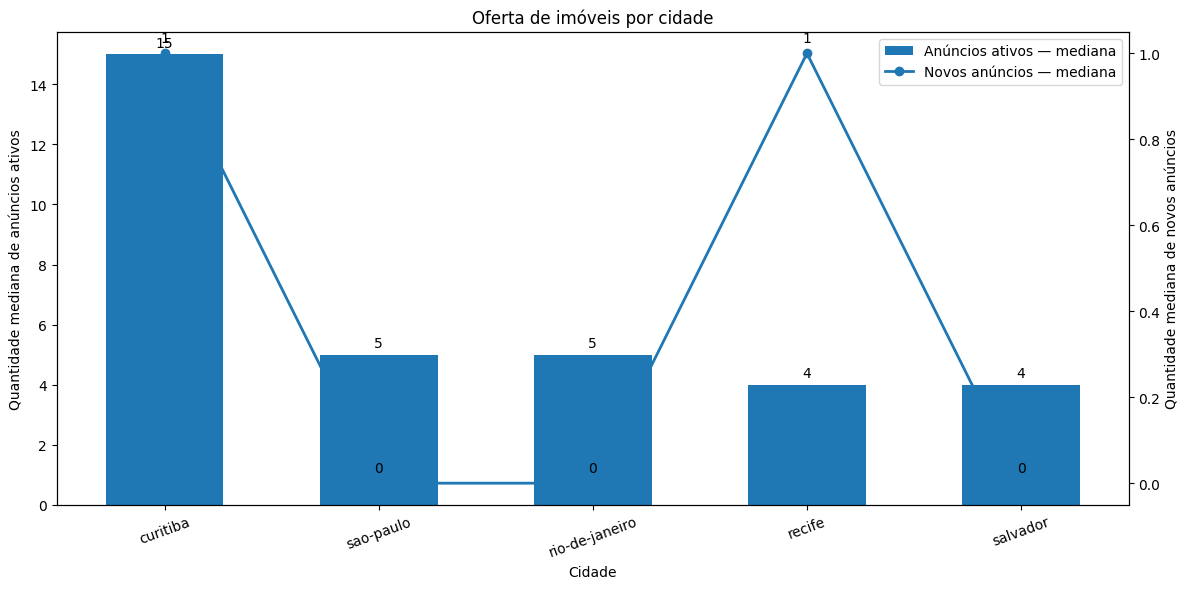

In [0]:
from pyspark.sql.functions import col, percentile_approx
import matplotlib.pyplot as plt
import numpy as np


# PERGUNTA 4 — COMPORTAMENTO DA OFERTA DE IMÓVEIS


# Agregação das métricas de oferta por cidade
resultado_p4 = (
    df_analise
    .groupBy(col("l.cidade").alias("cidade"))
    .agg(
        percentile_approx(
            col("f.anuncios_ativos_media_dia"), 0.5
        ).alias("mediana_anuncios_ativos"),

        percentile_approx(
            col("f.novos_anuncios"), 0.5
        ).alias("mediana_novos_anuncios")
    )
    .orderBy(col("mediana_anuncios_ativos").desc())
)

# Conversão apenas do resultado agregado para Pandas
pdf_p4 = resultado_p4.toPandas()

# Preparação do gráfico
x = np.arange(len(pdf_p4))
largura = 0.55

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras — anúncios ativos
barras = ax1.bar(
    x,
    pdf_p4["mediana_anuncios_ativos"],
    largura,
    label="Anúncios ativos — mediana"
)

ax1.set_xlabel("Cidade")
ax1.set_ylabel("Quantidade mediana de anúncios ativos")
ax1.set_xticks(x)
ax1.set_xticklabels(pdf_p4["cidade"], rotation=20)

# Valores sobre as barras
for barra in barras:
    altura = barra.get_height()
    ax1.annotate(
        f"{altura:,.0f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

# Segundo eixo — novos anúncios
ax2 = ax1.twinx()

linha = ax2.plot(
    x,
    pdf_p4["mediana_novos_anuncios"],
    marker="o",
    linewidth=2,
    label="Novos anúncios — mediana"
)

ax2.set_ylabel("Quantidade mediana de novos anúncios")

# Valores nos pontos da linha
for i, valor in enumerate(pdf_p4["mediana_novos_anuncios"]):
    ax2.annotate(
        f"{valor:,.0f}",
        (x[i], valor),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title("Oferta de imóveis por cidade")

# Legenda conjunta
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    linhas1 + linhas2,
    labels1 + labels2,
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 5.4.1 Interpretação do resultado

A análise evidencia diferenças na oferta de imóveis entre as cinco cidades presentes no conjunto de dados. Considerando a mediana da quantidade média diária de anúncios ativos, Curitiba apresentou o maior valor, com aproximadamente 15 anúncios, enquanto São Paulo e Rio de Janeiro apresentaram mediana de 5 anúncios. Recife e Salvador registraram os menores valores, ambos com mediana de aproximadamente 4 anúncios ativos.

Em relação à entrada de novos anúncios, os valores medianos foram baixos em todas as cidades. Curitiba e Recife apresentaram mediana de aproximadamente 1 novo anúncio por observação, enquanto São Paulo, Rio de Janeiro e Salvador apresentaram mediana igual a zero.

Esse resultado deve ser interpretado considerando a distribuição da variável `novos_anuncios`. Conforme identificado anteriormente na etapa de avaliação da qualidade dos dados, essa variável apresenta forte concentração em valores baixos, com mediana geral igual a zero. Portanto, uma mediana igual a zero não significa ausência total de novos anúncios nessas cidades durante todo o período, mas indica que pelo menos metade das observações consideradas apresenta valor igual a zero.

Dentro do conjunto de dados analisado, Curitiba se destaca pela maior disponibilidade mediana de anúncios ativos, enquanto a entrada de novos anúncios apresenta comportamento mais esparso. Os resultados representam exclusivamente os registros disponíveis na base utilizada neste projeto e não devem ser interpretados como indicadores oficiais da oferta imobiliária dessas cidades.

## 5.5 Pergunta 5 — Tempo de permanência dos imóveis no mercado

**Pergunta:** Existem diferenças no tempo médio de permanência dos imóveis no mercado entre as cidades e entre os tipos de transação?

Para investigar possíveis diferenças na permanência dos imóveis no mercado, será analisada a variável `dias_no_mercado_medio`, considerando simultaneamente a cidade e o tipo de transação — venda ou aluguel.

Como foram identificados valores extremos nessa variável durante a etapa de avaliação da qualidade dos dados, será utilizada a mediana das observações em cada combinação de cidade e tipo de transação. Essa medida reduz a influência dos valores extremos e permite uma comparação mais representativa entre os grupos presentes no conjunto de dados.

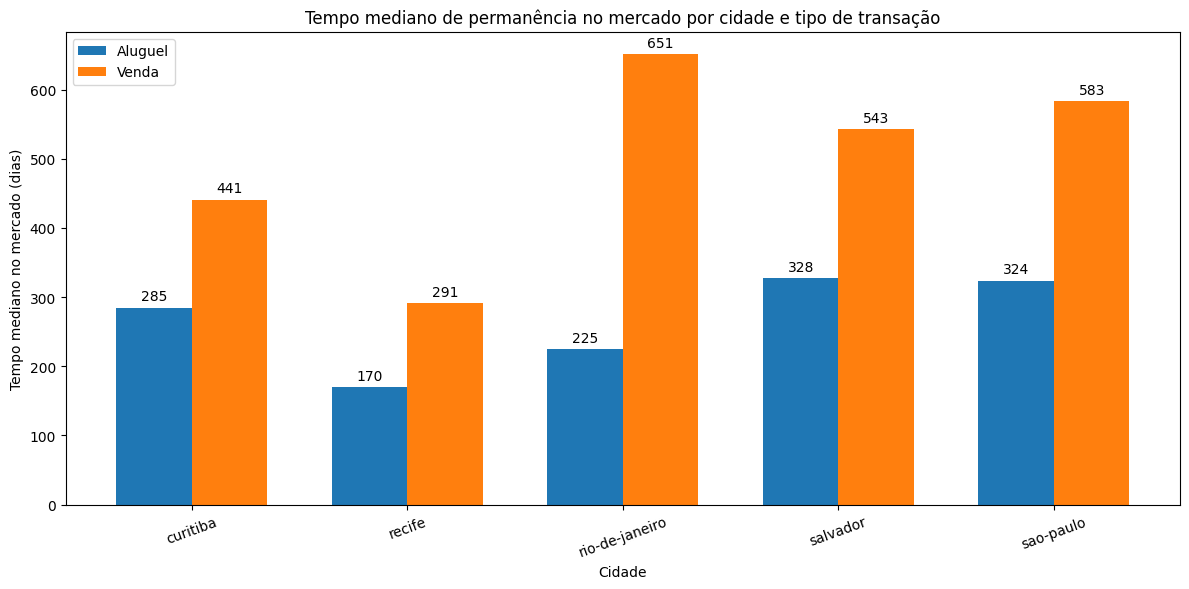

In [0]:
from pyspark.sql.functions import col, percentile_approx
import matplotlib.pyplot as plt
import numpy as np


# PERGUNTA 5 — TEMPO DE PERMANÊNCIA DOS IMÓVEIS NO MERCADO


# Relacionamento da tabela fato com as dimensões necessárias
df_p5 = (
    spark.table("mvp_imobiliario.gold.fato_mercado_imobiliario").alias("f")
    .join(
        spark.table("mvp_imobiliario.gold.dim_localidade").alias("l"),
        col("f.id_localidade") == col("l.id_localidade"),
        "inner"
    )
    .join(
        spark.table("mvp_imobiliario.gold.dim_transacao").alias("t"),
        col("f.id_transacao") == col("t.id_transacao"),
        "inner"
    )
)

# Mediana do tempo no mercado por cidade e tipo de transação
resultado_p5 = (
    df_p5
    .filter(col("f.dias_no_mercado_medio").isNotNull())
    .groupBy(
        col("l.cidade").alias("cidade"),
        col("t.transacao").alias("transacao")
    )
    .agg(
        percentile_approx(
            col("f.dias_no_mercado_medio"), 0.5
        ).alias("mediana_dias_mercado")
    )
)

# Conversão do resultado agregado para Pandas
pdf_p5 = resultado_p5.toPandas()

# Organização dos dados para o gráfico
grafico_p5 = (
    pdf_p5
    .pivot(
        index="cidade",
        columns="transacao",
        values="mediana_dias_mercado"
    )
    .fillna(0)
)

# Ordenação alfabética das cidades
grafico_p5 = grafico_p5.sort_index()

# Construção do gráfico
cidades = grafico_p5.index.tolist()
x = np.arange(len(cidades))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras_aluguel = ax.bar(
    x - largura / 2,
    grafico_p5["aluguel"],
    largura,
    label="Aluguel"
)

barras_venda = ax.bar(
    x + largura / 2,
    grafico_p5["venda"],
    largura,
    label="Venda"
)

# Valores sobre as barras
for barras in [barras_aluguel, barras_venda]:
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(
            f"{altura:,.0f}",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

ax.set_title(
    "Tempo mediano de permanência no mercado por cidade e tipo de transação"
)
ax.set_xlabel("Cidade")
ax.set_ylabel("Tempo mediano no mercado (dias)")
ax.set_xticks(x)
ax.set_xticklabels(cidades, rotation=20)
ax.legend()

plt.tight_layout()
plt.show()

### 5.5.1 Interpretação do resultado

Os resultados demonstram diferenças no tempo de permanência dos imóveis no mercado tanto entre as cidades quanto entre os tipos de transação. Em todas as cinco cidades analisadas, os imóveis destinados à venda apresentaram tempo mediano de permanência superior ao observado nos imóveis destinados ao aluguel.

No segmento de aluguel, Recife apresentou o menor tempo mediano, com aproximadamente 170 dias, seguido pelo Rio de Janeiro, com 225 dias, Curitiba, com 285 dias, São Paulo, com 324 dias, e Salvador, com 328 dias.

Para os imóveis destinados à venda, Recife também apresentou o menor tempo mediano de permanência, com aproximadamente 291 dias. Em seguida aparecem Curitiba, com 441 dias, Salvador, com 543 dias, São Paulo, com 583 dias, e Rio de Janeiro, que apresentou o maior valor, com aproximadamente 651 dias.

O Rio de Janeiro apresentou a maior diferença entre os tipos de transação: aproximadamente 225 dias para aluguel e 651 dias para venda. Esse comportamento indica que, dentro do conjunto de dados analisado, os anúncios destinados à venda permanecem disponíveis por períodos substancialmente maiores do que os anúncios destinados ao aluguel nessa cidade.

De maneira geral, a análise permite responder à pergunta proposta ao demonstrar que existem diferenças tanto entre as cidades quanto entre os tipos de transação, sendo observado, em todas as cidades da amostra, maior tempo mediano de permanência para imóveis destinados à venda.

Os resultados representam exclusivamente os registros disponíveis no conjunto de dados utilizado neste projeto e não devem ser interpretados como estimativas oficiais do tempo de comercialização ou locação dos imóveis nesses mercados.

## 5.6 Pergunta 6 — Bairros com os maiores preços medianos por metro quadrado

**Pergunta:** Quais bairros apresentam os maiores preços medianos por metro quadrado em cada cidade?

Para identificar as regiões com maior preço por metro quadrado dentro de cada cidade, será analisada a variável `mediana_m2`, agrupando os registros pelas dimensões de cidade e bairro.

Para reduzir a influência dos valores extremos identificados durante a etapa de avaliação da qualidade dos dados, será utilizada a mediana das observações disponíveis para cada bairro. Os registros em que `mediana_m2` estiver ausente serão desconsiderados exclusivamente neste cálculo.

Como o conjunto de dados possui grande quantidade de bairros, serão selecionados os cinco bairros com maior preço mediano por metro quadrado em cada uma das cinco cidades analisadas. Essa abordagem permite comparar as diferenças internas de cada mercado imobiliário sem tornar a visualização excessivamente carregada.

Os resultados devem ser interpretados exclusivamente no contexto do conjunto de dados utilizado neste projeto e do período nele representado.

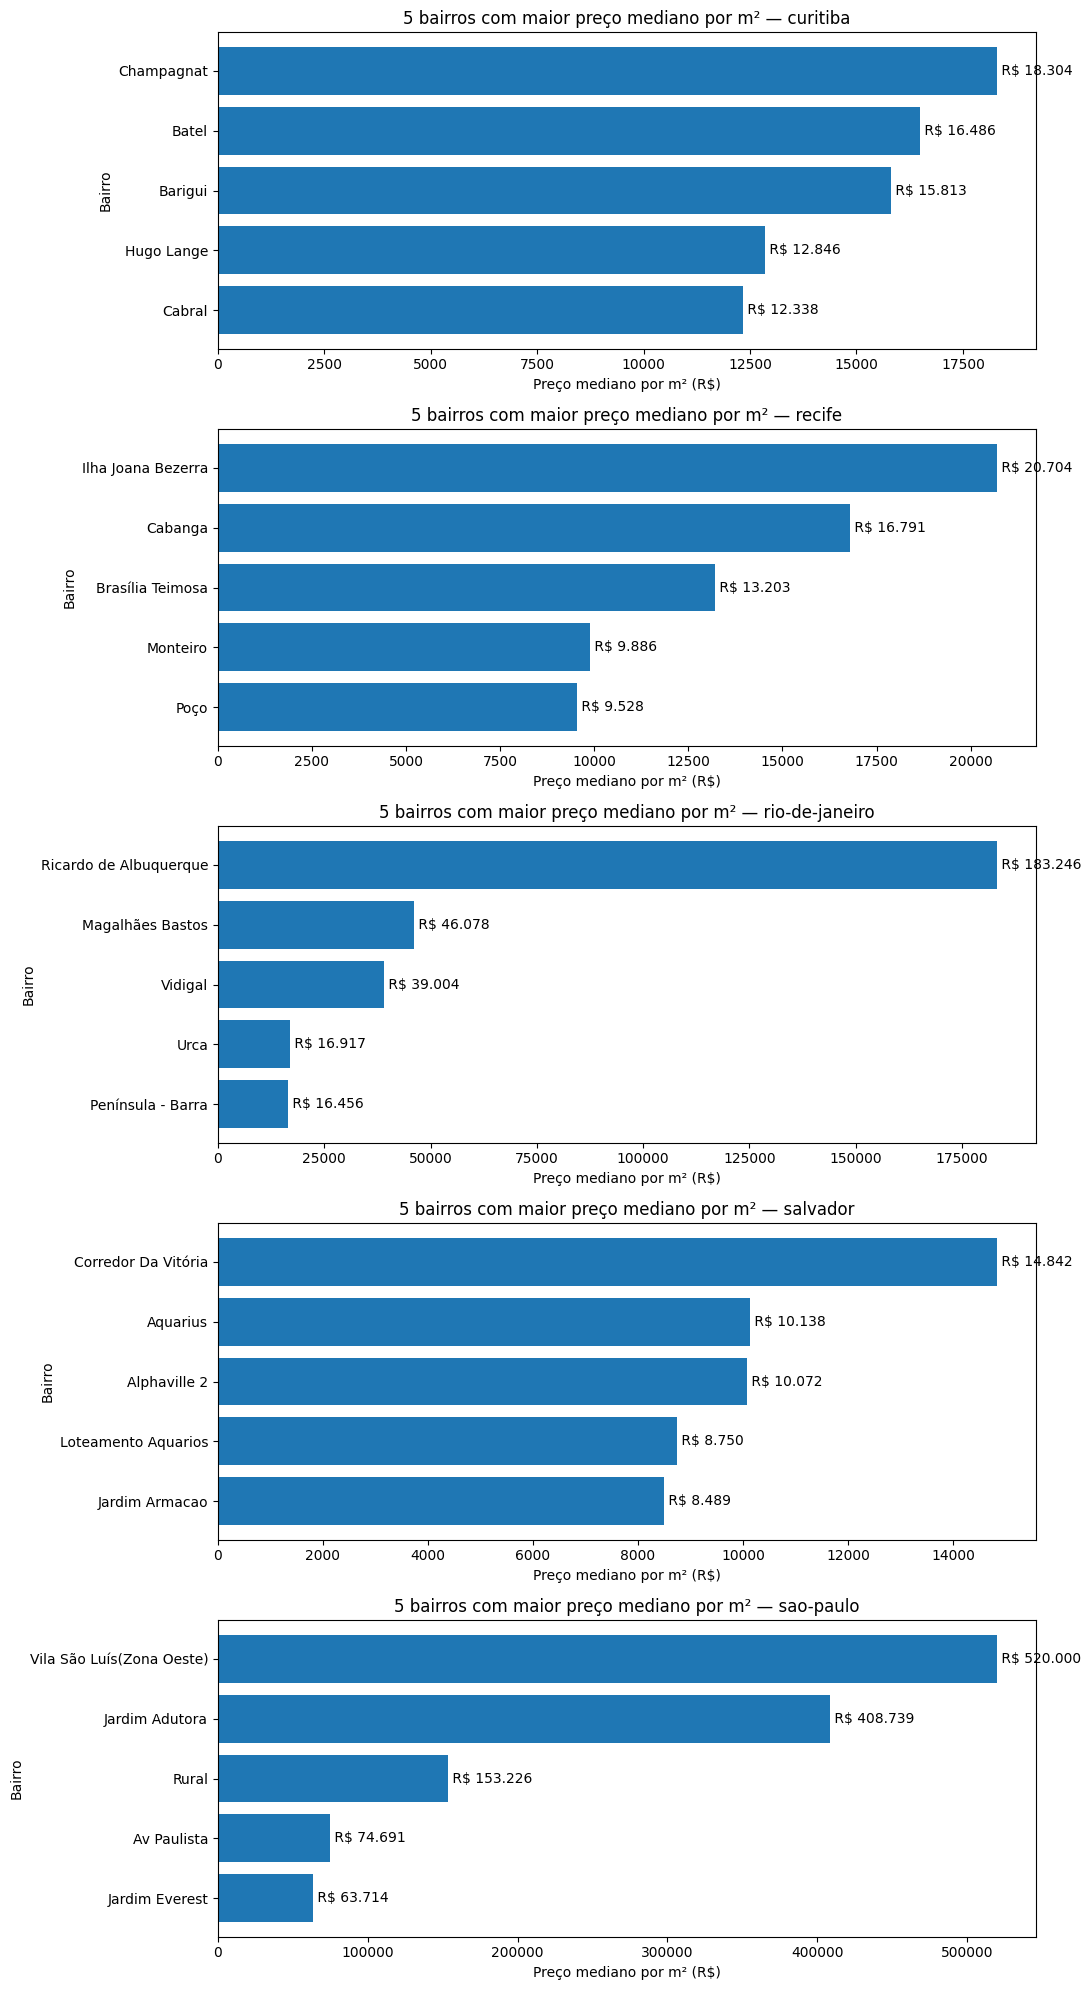

In [0]:
from pyspark.sql.functions import col, percentile_approx
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
import matplotlib.pyplot as plt

# Relacionamento da tabela fato com a dimensão de localidade
df_p6 = (
    spark.table("mvp_imobiliario.gold.fato_mercado_imobiliario").alias("f")
    .join(
        spark.table("mvp_imobiliario.gold.dim_localidade").alias("l"),
        col("f.id_localidade") == col("l.id_localidade"),
        "inner"
    )
)

# Cálculo do preço mediano por m² para cada bairro
resultado_p6 = (
    df_p6
    .filter(
        col("f.mediana_m2").isNotNull() &
        col("l.bairro").isNotNull() &
        (col("l.bairro") != "Não Informado")
    )
    .groupBy(
        col("l.cidade").alias("cidade"),
        col("l.bairro").alias("bairro")
    )
    .agg(
        percentile_approx(
            col("f.mediana_m2"), 0.5
        ).alias("preco_mediano_m2")
    )
)

# Ranking dos bairros dentro de cada cidade
janela = Window.partitionBy("cidade").orderBy(
    col("preco_mediano_m2").desc()
)

top_bairros_p6 = (
    resultado_p6
    .withColumn("ranking", row_number().over(janela))
    .filter(col("ranking") <= 5)
    .orderBy("cidade", "ranking")
)

# Conversão apenas do resultado agregado para Pandas
pdf_p6 = top_bairros_p6.toPandas()

# Criação de um gráfico para cada cidade
cidades = sorted(pdf_p6["cidade"].unique())

fig, axes = plt.subplots(
    len(cidades),
    1,
    figsize=(11, 4 * len(cidades))
)

if len(cidades) == 1:
    axes = [axes]

for ax, cidade in zip(axes, cidades):

    dados = (
        pdf_p6[pdf_p6["cidade"] == cidade]
        .sort_values("preco_mediano_m2", ascending=True)
    )

    barras = ax.barh(
        dados["bairro"],
        dados["preco_mediano_m2"]
    )

    ax.set_title(
        f"5 bairros com maior preço mediano por m² — {cidade}"
    )
    ax.set_xlabel("Preço mediano por m² (R$)")
    ax.set_ylabel("Bairro")

    for barra in barras:
        valor = barra.get_width()

        ax.text(
            valor,
            barra.get_y() + barra.get_height() / 2,
            f" R$ {valor:,.0f}".replace(",", "."),
            va="center"
        )

plt.tight_layout()
plt.show()

### 5.6.1 Interpretação do resultado

A análise evidencia diferenças relevantes entre os bairros com maiores preços medianos por metro quadrado nas cinco cidades estudadas. Em Curitiba, os maiores valores foram observados em Champagnat, com aproximadamente R$ 18.304/m², seguido por Batel (R$ 16.486/m²), Barigui (R$ 15.813/m²), Hugo Lange (R$ 12.846/m²) e Cabral (R$ 12.338/m²).

Em Recife, Ilha Joana Bezerra apresentou o maior valor, com aproximadamente R$ 20.704/m², seguida por Cabanga (R$ 16.791/m²), Brasília Teimosa (R$ 13.203/m²), Monteiro (R$ 9.886/m²) e Poço (R$ 9.528/m²). Em Salvador, destacaram-se Corredor da Vitória, com aproximadamente R$ 14.842/m², Aquarius (R$ 10.138/m²), Alphaville 2 (R$ 10.072/m²), Loteamento Aquarius (R$ 8.750/m²) e Jardim Armação (R$ 8.489/m²).

No Rio de Janeiro e em São Paulo foram observados valores consideravelmente superiores aos encontrados nos demais municípios. No Rio de Janeiro, Ricardo de Albuquerque apresentou aproximadamente R$ 183.246/m², enquanto, em São Paulo, Vila São Luís (Zona Oeste) alcançou aproximadamente R$ 520.000/m² e Jardim Adutora R$ 408.739/m².

Esses valores devem ser interpretados com cautela. A etapa de avaliação da qualidade dos dados identificou a presença de valores extremos na variável `mediana_m2`. Portanto, os valores elevados observados em determinados bairros podem refletir características ou anomalias existentes no conjunto de dados e não devem ser interpretados automaticamente como preços representativos do mercado imobiliário dessas localidades.

A análise demonstra, assim, que existe elevada heterogeneidade nos preços por metro quadrado tanto entre cidades quanto entre bairros de uma mesma cidade. Também evidencia a importância da etapa de qualidade de dados para contextualizar os resultados analíticos e evitar conclusões inadequadas a partir de valores extremos.

Os resultados representam exclusivamente os registros presentes no conjunto de dados utilizado neste projeto e no período analisado, não constituindo estimativas oficiais dos preços praticados no mercado imobiliário dessas cidades.

## 5.7 Discussão Geral dos Resultados

A análise dos dados permitiu responder às seis perguntas de negócio propostas para o projeto e identificar diferenças relevantes no comportamento do mercado imobiliário das cinco cidades presentes no conjunto de dados: Curitiba, Recife, Rio de Janeiro, Salvador e São Paulo.

Em relação aos preços, foram observadas diferenças tanto entre as cidades quanto entre os tipos de transação. Na comparação geral, Curitiba apresentou o maior preço mediano por metro quadrado entre as cidades analisadas, enquanto Salvador apresentou o menor. Quando venda e aluguel foram avaliados separadamente, também foram identificadas diferenças importantes, demonstrando que a comparação do mercado depende do tipo de transação considerado.

A análise temporal mostrou que as cidades não apresentaram um comportamento uniforme durante o período estudado. Curitiba permaneceu com os maiores valores ao longo da série e apresentou crescimento nos meses finais, enquanto São Paulo demonstrou maior estabilidade. Rio de Janeiro apresentou tendência geral de crescimento, Salvador registrou elevação mais evidente ao final da série e Recife apresentou trajetória predominantemente decrescente. Esses comportamentos demonstram a importância da dimensão temporal para a compreensão das variações existentes nos dados.

A avaliação da oferta também revelou diferenças entre as cidades. Curitiba apresentou a maior mediana de anúncios ativos, enquanto a entrada de novos anúncios apresentou valores relativamente baixos em todas as localidades. Como a variável `novos_anuncios` possui forte concentração em valores baixos e mediana geral igual a zero, seus resultados devem ser interpretados considerando essa característica da distribuição.

Quanto ao tempo de permanência dos imóveis no mercado, os dados mostraram que, em todas as cinco cidades, os anúncios destinados à venda apresentaram tempo mediano de permanência superior aos anúncios destinados ao aluguel. Também foram observadas diferenças relevantes entre as cidades, indicando comportamentos distintos na duração dos anúncios presentes na base.

A análise por bairro evidenciou ainda maior heterogeneidade dentro das próprias cidades. Alguns bairros apresentaram preços medianos por metro quadrado muito superiores aos demais. Entretanto, a etapa de qualidade dos dados já havia identificado a presença de valores extremos na variável `mediana_m2`, exigindo cautela na interpretação desses resultados. Dessa forma, valores muito elevados observados em determinados bairros não devem ser automaticamente considerados representativos dos respectivos mercados imobiliários.

De maneira geral, o projeto demonstra como um pipeline de Engenharia de Dados pode transformar dados brutos em informações estruturadas para análise. A organização das informações nas camadas Bronze, Silver e Gold permitiu preservar os dados originais, realizar tratamentos e padronizações e disponibilizar um modelo dimensional voltado ao consumo analítico.

A avaliação da qualidade dos dados também se mostrou fundamental para a interpretação dos resultados. A identificação de valores ausentes, valores extremos, características das distribuições e verificação de consistência permitiu compreender limitações existentes na base e evitar que os resultados fossem analisados sem o devido contexto.

Assim, as análises realizadas permitem compreender diferenças de preço, evolução temporal, oferta, permanência dos anúncios e comportamento dos bairros dentro do conjunto de dados estudado. Os resultados, entretanto, representam exclusivamente a base utilizada neste projeto e o período nela disponível, não devendo ser interpretados como indicadores oficiais ou como representação integral dos mercados imobiliários das cidades analisadas.